In [227]:
import numpy as np
import matplotlib.pyplot as plt

Cvičení 3.1: Reshape a indexování
Lehké
Vytvoř pole čísel 1 až 20 (np.arange). Přetvoř ho na matici 4×5. Vypiš: (a) třetí řádek,
(b) druhý sloupec, (c) prvek na pozici [2, 3], (d) submatici řádků 1-2 a sloupců 2-4.
Očekávaný výstup:
(a) [11, 12, 13, 14, 15]
(b) [2, 7, 12, 17]
(c) 14
(d) [[8,9,10],[13,14,15]]

In [228]:
pole1 = np.arange(1, 21, 1)
reshaped_pole1 = pole1.reshape(4, 5)
print(f"Reshaped pole:\n{reshaped_pole1}")
print(f"Treti radek:\n{reshaped_pole1[2,]}")
print(f"Druhy sloupec:\n{reshaped_pole1[:,1]}")
print(f"Prvek na pozici [2, 3]:\n{reshaped_pole1[2, 3]}")
print(f"Submatice radku 1-2 a sloupcu 3-4:\n{reshaped_pole1[1:3, 2:5]}")    # prvni cislo = index od kdy, druhe cislo = index, ktery je horni zavora, intervalu se nedotyka

Reshaped pole:
[[ 1  2  3  4  5]
 [ 6  7  8  9 10]
 [11 12 13 14 15]
 [16 17 18 19 20]]
Treti radek:
[11 12 13 14 15]
Druhy sloupec:
[ 2  7 12 17]
Prvek na pozici [2, 3]:
14
Submatice radku 1-2 a sloupcu 3-4:
[[ 8  9 10]
 [13 14 15]]


Cvičení 3.2: Portfolio výnos
Střední
Máš 3 aktiva (BTC, ETH, SOL) s váhami [0.5, 0.3, 0.2]. Generuj 252 dnů náhodných
výnosů pro každé aktivum (np.random.normal, mean=0.0005, std=0.02, seed=42).
Spočítej denní výnosy portfolia pomocí maticového násobení. Vypiš průměrný denní
výnos portfolia a anualizovaný výnos (× 252).

In [229]:
weights = np.array([0.5, 0.3, 0.2]) # BTC 50 %, ETH 30 %, SOL 20 %
np.random.seed(42)
gen_returns = np.random.normal(0.0005, 0.02, (252, 3)) # generujeme matici 252ř 3s
portf_returns = gen_returns @ weights   # denni vynosy
print(f"Prumerny denni vynos z portfolia (BTC, ETH, SOL):\n{portf_returns.mean(axis=0)*100:.4f} %")
print(f"Anualizovany vynos:\n{portf_returns.mean()*100*252:.2f} %")

Prumerny denni vynos z portfolia (BTC, ETH, SOL):
0.0338 %
Anualizovany vynos:
8.52 %


Cvičení 3.3: Monte Carlo simulace
Střední
Simuluj 1000 cest ceny aktiva s počáteční cenou 1000 USD, denním průměrným
výnosem 0.0003, volatilitou 0.025, po dobu 180 dnů. Vykresli všechny cesty. Spočítej
pravděpodobnost, že cena po 180 dnech bude vyšší než počáteční.

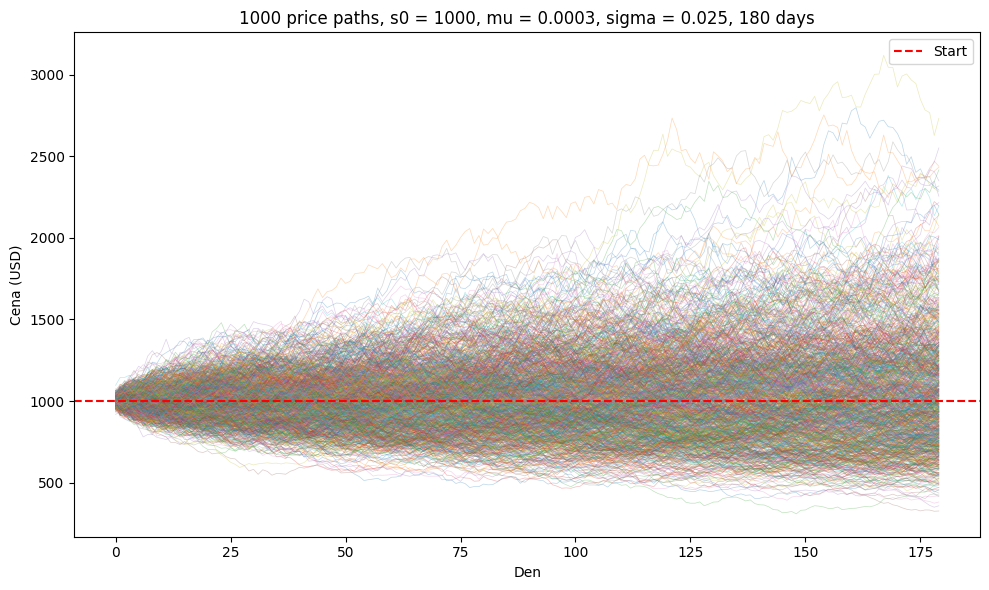

In [232]:
s0 = 1000   # $USD
mu = 0.0003
sigma = 0.025
days = 180
n_paths = 1000

np.random.seed(42)
vynosy = np.random.normal(mu, sigma, (days, n_paths))   # generujeme 2D dny ř. ruzne cesty s

price_paths = s0 * np.cumprod(1 + vynosy, axis=0)
# pro pochopeni cumprod (cumulative product)
# vynos 12 % (0.12) z $1000 je $1120, spocteno jako $1000 * 1.12, NEBOLI $1000 * (1 + vynos)

# vizualizace obslehla - neni cil teto lekce imo
plt.figure(figsize=(10, 6))
plt.plot(price_paths, alpha=0.3, linewidth=0.5)
plt.axhline(y=s0, color="red", linestyle="--", label="Start")
plt.title("1000 price paths, s0 = 1000, mu = 0.0003, sigma = 0.025, 180 days")
plt.xlabel("Den")
plt.ylabel("Cena (USD)")
plt.legend()
plt.tight_layout()
plt.savefig("F0_L3-challenge_3.png", dpi=150)
plt.show()

